In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import openpyxl
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
import xgboost as xgb
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from skopt.space import Integer, Real
from skopt import BayesSearchCV
import shap
from sklearn.inspection import permutation_importance

Budowa modelu XGBoost na podstawie danych bankowych
==============

**Joanna Pokora**

## Wstęp

Celem raportu jest budowa modelu XGBoost przewidującego, czy klient zgodzi się na subskrypcję lokaty terminowej na podstawie cech demograficznych i informacji o kontakcie marketingowym. Na początku przeprowadzona zostanie analiza eksploracyjna, obejmująca weryfikację statystyk opisowych, rozkładów zmiennych oraz zależności między nimi. Następnie na danych treningowych zbudowane zostaną modele z domyślnymi i zoptymalizowanymi hiperparametrami oraz zmiennymi typu *dummy*. Dla najlepszego modelu przeprowadzona zostanie analiza jakości z użyciem danych testowych i treningowych, wykorzystująca elementy takie jak macierz pomyłek, miara GAIN oraz wykres SHAP.

In [3]:
data = pd.read_csv("C:/Users/Baller/Desktop/magisterka/bankowosc/raport2/dane_list2.csv", sep = ";")

## Przygotowanie danych

Zbór danych bankowych zawiera 45 211 obserwacji i obejmuje następujące informacje o klientach:

* *age* - wiek (ciągła),
* *job* - zawód (kategoryczna: "management", "technician", "entrepreneur", "lightblue-collar", "unknown", "retired", "admin.", "services", "self-employed",
  "unemployed", "housemaid", "student"),
* *marital* - stan cywilny (kategoryczna: "married", "single", "divorced"),
* *education* - poziom wykształcenia (kategoryczna: "tertiary", "secondary", "unknown", "primary"),
* *default* - czy klient ma zaległości w spłacie kredytu (binarna),
* *balance* - średnie roczne saldo na koncie (ciągła),
* *housing* - czy klient posiada kredyt hipoteczny (binarna),
* *loan* - czy klient posiada kredyt gotówkowy (binarna),
* *y* - czy klient zdecydował się na subskrypcję lokaty terminowej (binarna, zmienna zależna),
* *campaign* - liczba kontaktów z klientem w bieżącej kampanii (ciągła),
* *pdays* - liczba dni od ostatniego kontaktu w poprzedniej kampanii (ciągła, -1 
oznacza brak wcześniejszego kontaktu),
* *previous* - liczba kontaktów z klientem przed bieżącą kampanią (ciągła),
* *poutcome* - wynik poprzedniej kampanii marketingowej (kategoryczna: "unknown", "failure", "other", "success").

Dodatkowo znamy również informacje o ostatnim kontakcie w bieżącej kampanii:
* *contact* - typ komunikacji (kategoryczna: "unknown", "cellular", "telephone"),
* *day* - dzień kontaktu (kategoryczna),
* *month* - miesiąc kontaktu (kategoryczna),
* *duration* - czas trwania (ciągła).


Każda obserwacja reprezentuje jednego klienta, co wnioskujemy na podstawie braku powtórzeń. Wszystkim obserwacjom możemy więc przypisać unikalne id. W zbiorze nie ma również brakujących danych.

Na wstępie kodujemy binarnie wartości zmiennej zależnej (1=*yes*, 0=*no*). Następnie wszystkie kolumny kategoryczne zamieniamy na numeryczne. Zaktualizowane dane dzielimy na zbiory treningowy i testowy w proporcji 80:20.

In [4]:
dat = data.reset_index()
dat = dat.rename(columns = {"index": "id"})

In [5]:
missing_values = dat.isna().sum()
duplicates = dat.duplicated().sum()

In [6]:
dat = dat.replace({"yes": 1, "no": 0})

In [7]:
encoder = LabelEncoder()

for col in dat.select_dtypes(include = "object").columns:
    dat[col] = encoder.fit_transform(dat[col])

encoded = encoder.fit_transform(dat[["month"]])
dat["month"] = encoded.astype(int) + 1

In [8]:
from sklearn.model_selection import train_test_split

cols = set(dat.columns) - {"id", "y"}
cols = list(cols)

X_train, X_test, y_train, y_test = train_test_split(dat[cols], dat.y,
                                                   test_size = 0.2,
                                                   random_state = 20)

## Analiza eksploracyjna

Na wstępie przeanalizujmy i porównajmy statystyki opisowe zmiennych objaśniających dla danych treningowych oraz testowych, przedstawione w poniższych tabelach.

In [9]:
X_train.describe()

,job,default,age,loan,education,poutcome,previous,housing,month,duration,day,contact,marital,balance,campaign,pdays
count,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000
mean,4.338670,0.018663,40.947716,0.161330,1.220941,2.559970,0.582393,0.556929,6.531243,258.805187,15.814919,0.641340,1.167054,1365.310136,2.759207,40.295233
std,3.276785,0.135333,10.630946,0.367841,0.746518,0.988751,2.387158,0.496755,3.004373,259.943461,8.323935,0.898281,0.606931,3035.755412,3.052023,100.450310
min,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,-8019.000000,1.000000,-1.000000
25%,1.000000,0.000000,33.000000,0.000000,1.000000,3.000000,0.000000,0.000000,4.000000,103.000000,8.000000,0.000000,1.000000,70.000000,1.000000,-1.000000
50%,4.000000,0.000000,39.000000,0.000000,1.000000,3.000000,0.000000,1.000000,7.000000,180.000000,16.000000,0.000000,1.000000,445.000000,2.000000,-1.000000
75%,7.000000,0.000000,48.000000,0.000000,2.000000,3.000000,0.000000,1.000000,9.000000,319.000000,21.000000,2.000000,2.000000,1431.000000,3.000000,-1.000000
max,11.000000,1.000000,94.000000,1.000000,3.000000,3.000000,275.000000,1.000000,12.000000,4918.000000,31.000000,2.000000,2.000000,98417.000000,51.000000,871.000000


In [10]:
X_test.describe()

,job,default,age,loan,education,poutcome,previous,housing,month,duration,day,contact,marital,balance,campaign,pdays
count,9043.000000,9043.000000,9043.000000,9043.000000,9043.000000,9043.000000,9043.000000,9043.000000,9043.000000,9043.000000,9043.000000,9043.000000,9043.000000,9043.000000,9043.000000,9043.000000
mean,4.344134,0.015482,40.890191,0.155811,1.240296,2.559991,0.572045,0.551476,6.490103,255.594935,15.772421,0.635851,1.170408,1350.121088,2.782373,39.808249
std,3.256271,0.123465,10.570353,0.362696,0.753730,0.990343,1.932785,0.497371,3.016981,247.628123,8.317013,0.896666,0.613424,3080.679425,3.275652,98.836715
min,0.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,-4057.000000,1.000000,-1.000000
25%,1.000000,0.000000,33.000000,0.000000,1.000000,3.000000,0.000000,0.000000,4.000000,104.000000,8.000000,0.000000,1.000000,81.000000,1.000000,-1.000000
50%,4.000000,0.000000,39.000000,0.000000,1.000000,3.000000,0.000000,1.000000,7.000000,181.000000,16.000000,0.000000,1.000000,460.000000,2.000000,-1.000000
75%,7.000000,0.000000,48.000000,0.000000,2.000000,3.000000,0.000000,1.000000,9.000000,319.000000,21.000000,2.000000,2.000000,1413.500000,3.000000,-1.000000
max,11.000000,1.000000,95.000000,1.000000,3.000000,3.000000,51.000000,1.000000,12.000000,3366.000000,31.000000,2.000000,2.000000,102127.000000,63.000000,854.000000


In [76]:
train_mean = y_train.mean()
test_mean = y_test.mean()

Zbiór treningowy zawiera 336168 obserwacji, natomiast testowy 9043, co zgadza się z przyjętą wcześniej proporcją. W ogólności, statystyki obliczone na podstawie zbioru treningowego i testowego są podobne. Wstępnie sugeruje to reprezentatywność obu podzbiorów w stosunku do całego zbioru danych.

Warto zauważyć, że średnie roczne saldo na koncie klienta może być ujemne, co oznacza, że niektóre osoby mają długi. Ponadto średnia zmiennej *balance* jest dużo większa od jej mediany, a maksymalna wartość znacznie przewyższa trzeci kwartyl, wskazującym tym samym na duże, odstające wartości. Są one jednak obecne zarówno w zbiorze treningowym jak i testowym. Podobnie, duże maksymalne wartości w stosunku do reszty obserwujemy dla czasu trwania ostatniego kontaktu w bieżącej kampanii oraz całkowitej liczby kontaktów w trakcie niej, liczby kontaktów przed bieżącą kampanią, wieku oraz liczby dni od ostatniego kontaktu w poprzedniej kampanii. W ostatnim przypadku spodziewamy się, że większość klientów nie była wcześniej kontaktowana. Można też zauważyć, że maksymalne wartości zmiennej *previous* różnią się pomiędzy podzbiorami, wskazując na obecność większych obserwacji odstających w zbiorze treningowym.

Średnia wartość zmiennej wynikowej w zbiorze treningowym to 0.117, natomiast w zbiorze testowym - 0.116, co potwierdza odpowiedni podział danych. Wiadomo również, że znacznie więcej klientów nie zdecydowało się na subskrypcję lokaty terminowej. Tak znaczna różnica mogłaby wpływać na obciążenie modelu, na przykład gdybyśmy stosowali regresję logistyczną, jednak model XGBoost jest bardziej odporny na różnicę frakcji. Wobec tego nie będziemy modyfikować zbioru pod tym kątem.

Aby mieć dokładniejszy wgląd w rozkłady zmiennych, przeanalizujmy boxploty, histogramy oraz wykresy słupkowe ich wartości.

In [12]:
cont = ["age", "duration", "pdays", "balance", "campaign", "previous"]

X_train_long = X_train.reset_index()
X_train_long = pd.melt(X_train_long, value_vars = cont)
X_train_long["dataset"] = ["train"] * len(X_train_long)

X_test_long = X_test.reset_index()
X_test_long = pd.melt(X_test_long, value_vars = cont)
X_test_long["dataset"] = ["test"] * len(X_test_long)

dat_long = pd.concat([X_train_long, X_test_long])

Text(0.5, 1.05, 'Boxploty zmiennych ciągłych')

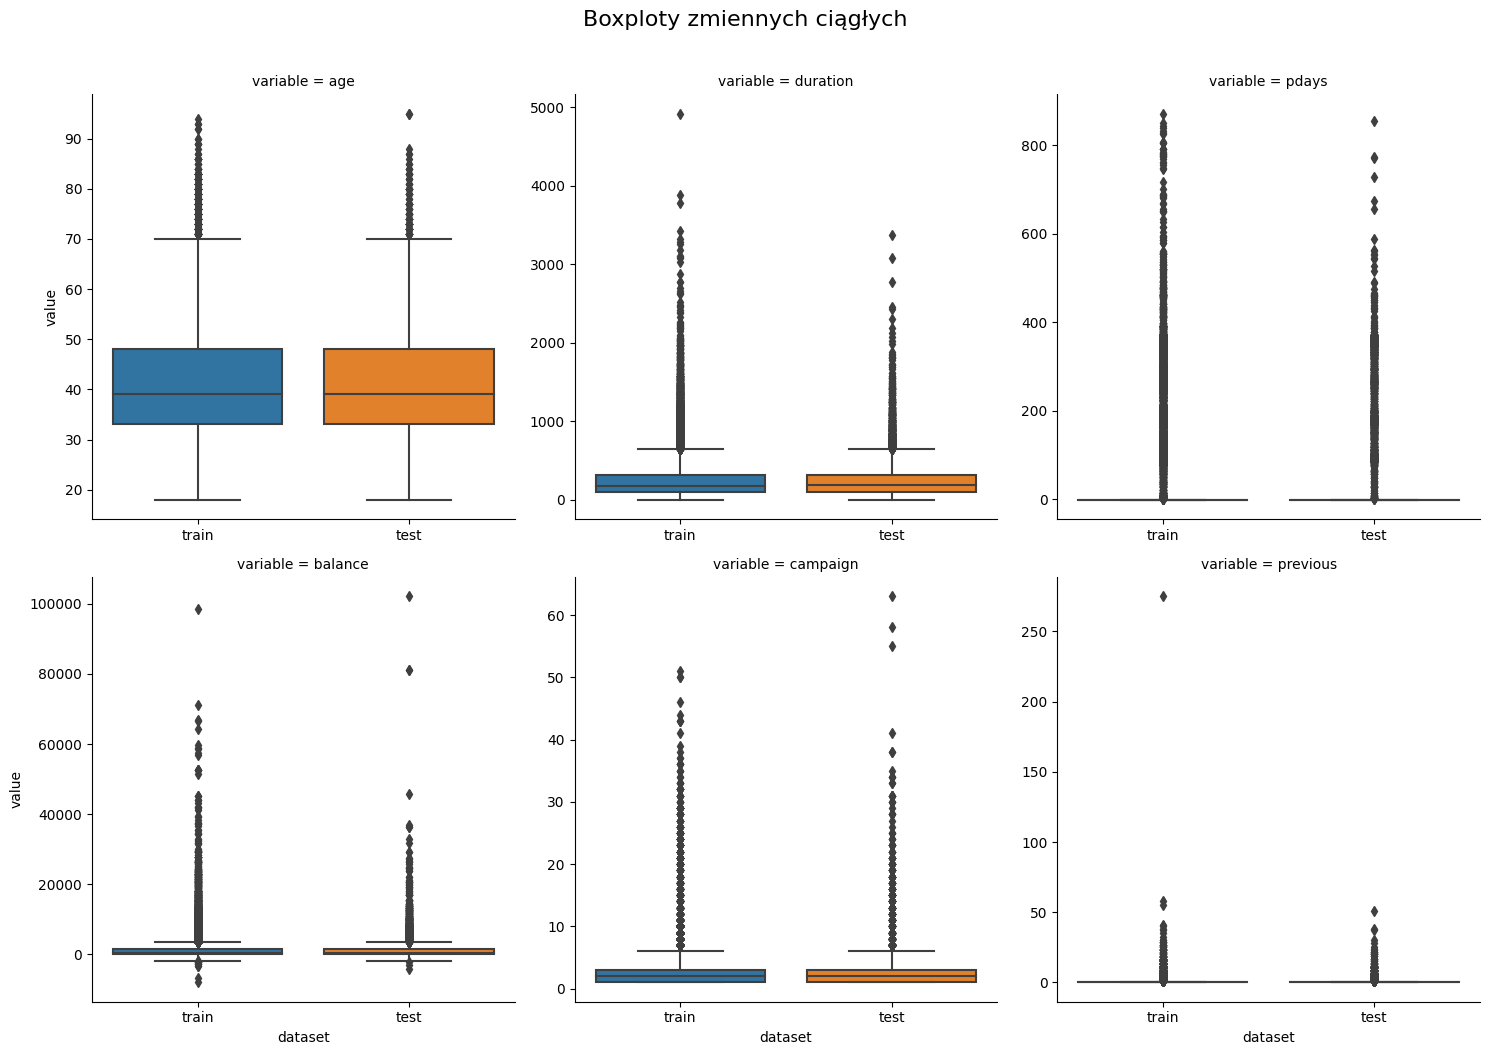

In [13]:
boxplots = sns.catplot(
    data=dat_long, y='value',
    col='variable', kind='box', col_wrap=3,
    sharey = False, sharex = False,
    x = "dataset"
)

boxplots.fig.suptitle("Boxploty zmiennych ciągłych", y=1.05, fontsize=16)

Zgodnie z tym, co zauważyliśmy poprzednio, wartości zmiennych są dość równo rozłożone pomiędzy zbiór treningowy i testowy, oprócz tych dla zmiennej *previous*. Możemy również dostrzec pojedynczą większą wartość zmiennej *duration* w zbiorze treningowym, jednak biorąc pod uwagę, że jest to czas trwania ostatniego kontaktu w sekundach, to przyjmujemy, że obserwowana różnica nie jest znacząca. Przyjrzyjmy się natomiast obserwacji posiadającej odstającą wartość dla zmiennej *previous*.

In [14]:
dat[dat["previous"] == 275]

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
29182,29182,40,4,1,2,0,543,1,0,0,2,4,349,2,262,275,1,0


Obserwacja ta dla żadnej zmiennej za wyjątkiem *previous* nie zawiera wartości ekstremalnej. Ponieważ liczba kontaktów z tą osobą w poprzedniej kampanii różni się znacznie od pozostałych wartości, a ponadto osoba ta nie zdecydowała się na subskrypcję lokaty terminowej, to wykluczamy tę obserwację, aby nie wpłynęła ona negatywnie na obciążenie modelu.

Sprawdźmy boxploty wartości zmiennej *previous* po wykluczeniu obserwacji odstającej.

Text(0.5, 1.05, 'Boxploty zmiennej previous po usunięciu obserwacji odstającej')

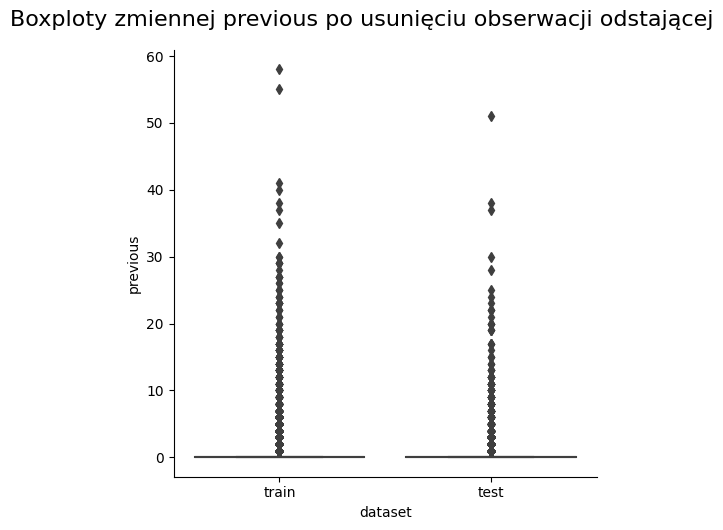

In [15]:
dat = dat[dat["id"] != 29182]
X_train = X_train[X_train.index != 29182]
y_train = y_train[y_train.index != 29182]

X_train_long = X_train.reset_index()
X_train_long = pd.melt(X_train_long, value_vars = cont)
X_train_long["dataset"] = ["train"] * len(X_train_long)

dat_long = pd.concat([X_train_long, X_test_long])

previous_long = pd.concat([X_train[["previous"]], X_test[["previous"]]], ignore_index = True)
previous_long["dataset"] = ["train"] * len(X_train) + ["test"] * len(X_test)

previous_boxplots = sns.catplot(
    data=previous_long, y='previous', kind='box', x = "dataset"
)

previous_boxplots.fig.suptitle("Boxploty zmiennej previous po usunięciu obserwacji odstającej", y=1.05, fontsize=16)

Po wyeliminowaniu jednego klienta, wartości zmiennej układają się mniej więcej porówno między zbiorem treningowym i testowym.

Kolejne wykresy przedstawiają histogramy wartości zmiennych ciągłych.

Text(0.5, 1.05, 'Histogramy zmiennych ciągłych')

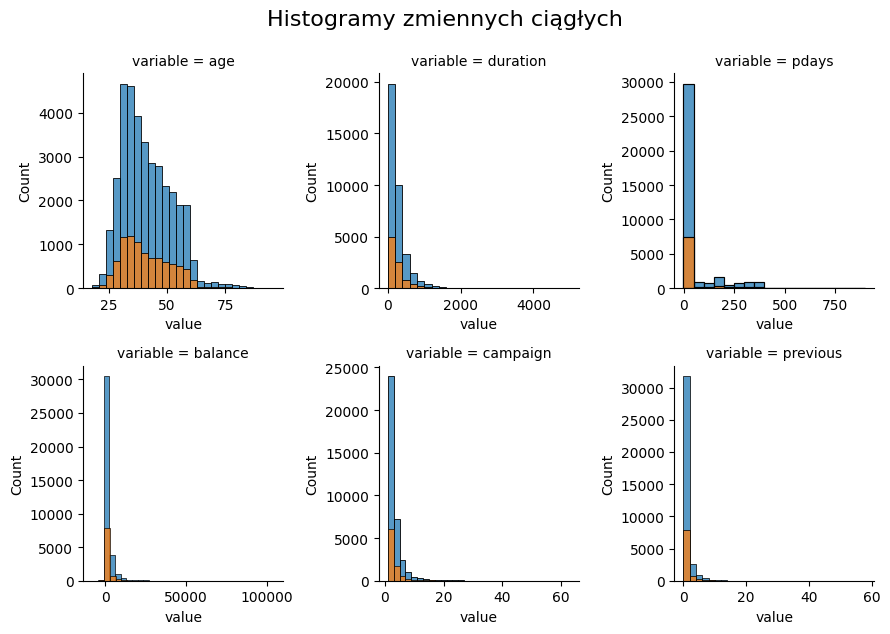

In [16]:
bin_map = {
    'age': 3,
    'duration': 200,
    'pdays': 50,
    "balance": 3500,
    "campaign": 2,
    "previous": 2
}

def custom_histplot(data, color, **kwargs):
    var = data['variable'].iloc[0]
    binwidth = bin_map.get(var)
    sns.histplot(data, x='value', binwidth=binwidth, color=color, **kwargs)

# Use FacetGrid
histograms = sns.FacetGrid(
    dat_long,
    col='variable',
    col_wrap=3,
    sharex=False,
    sharey=False,
    hue = "dataset"
)

histograms_fig = histograms.map_dataframe(custom_histplot)

histograms_fig.fig.suptitle("Histogramy zmiennych ciągłych", y=1.05, fontsize=16)

Rozkłady wszystkich zmiennych poza wiekiem są skoncentrowane wokół zera. Jednocześnie dla każdej zmiennej obserwujemy ciężkie ogony. Najwięcej osób jest w wieku 30-35 lat, natomiast po przekroczeniu 60 lat liczba osób znacznie spada. Rozkłady każdej zmiennej w zbiorze treningowym i testowym są podobne, co potwierdza dobrą jakość podziału danych.

Poniżej przedstawione zostały wykresy słupkowe wartości zmiennych kategorycznych.

In [17]:
categor = ["job", "marital", "education", "default", "housing", "loan", "contact", "day", "month", "poutcome"]

X_train_long_cat = data.loc[data.index.isin(X_train.index)].reset_index()
X_train_long_cat = pd.melt(X_train_long_cat, value_vars = categor)
X_train_long_cat["dataset"] = ["train"] * len(X_train_long_cat)

X_test_long_cat = data.loc[data.index.isin(X_test.index)].reset_index()
X_test_long_cat = pd.melt(X_test_long_cat, value_vars = categor)
X_test_long_cat["dataset"] = ["test"] * len(X_test_long_cat)

dat_long_cat = pd.concat([X_train_long_cat, X_test_long_cat])

month_to_num = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4,
    "may": 5, "jun": 6, "jul": 7, "aug": 8,
    "sep": 9, "oct": 10, "nov": 11, "dec": 12
}

dat_long_cat.loc[dat_long_cat["variable"] == "month", "value"] = (
    dat_long_cat.loc[dat_long_cat["variable"] == "month", "value"]
    .replace(month_to_num)
)

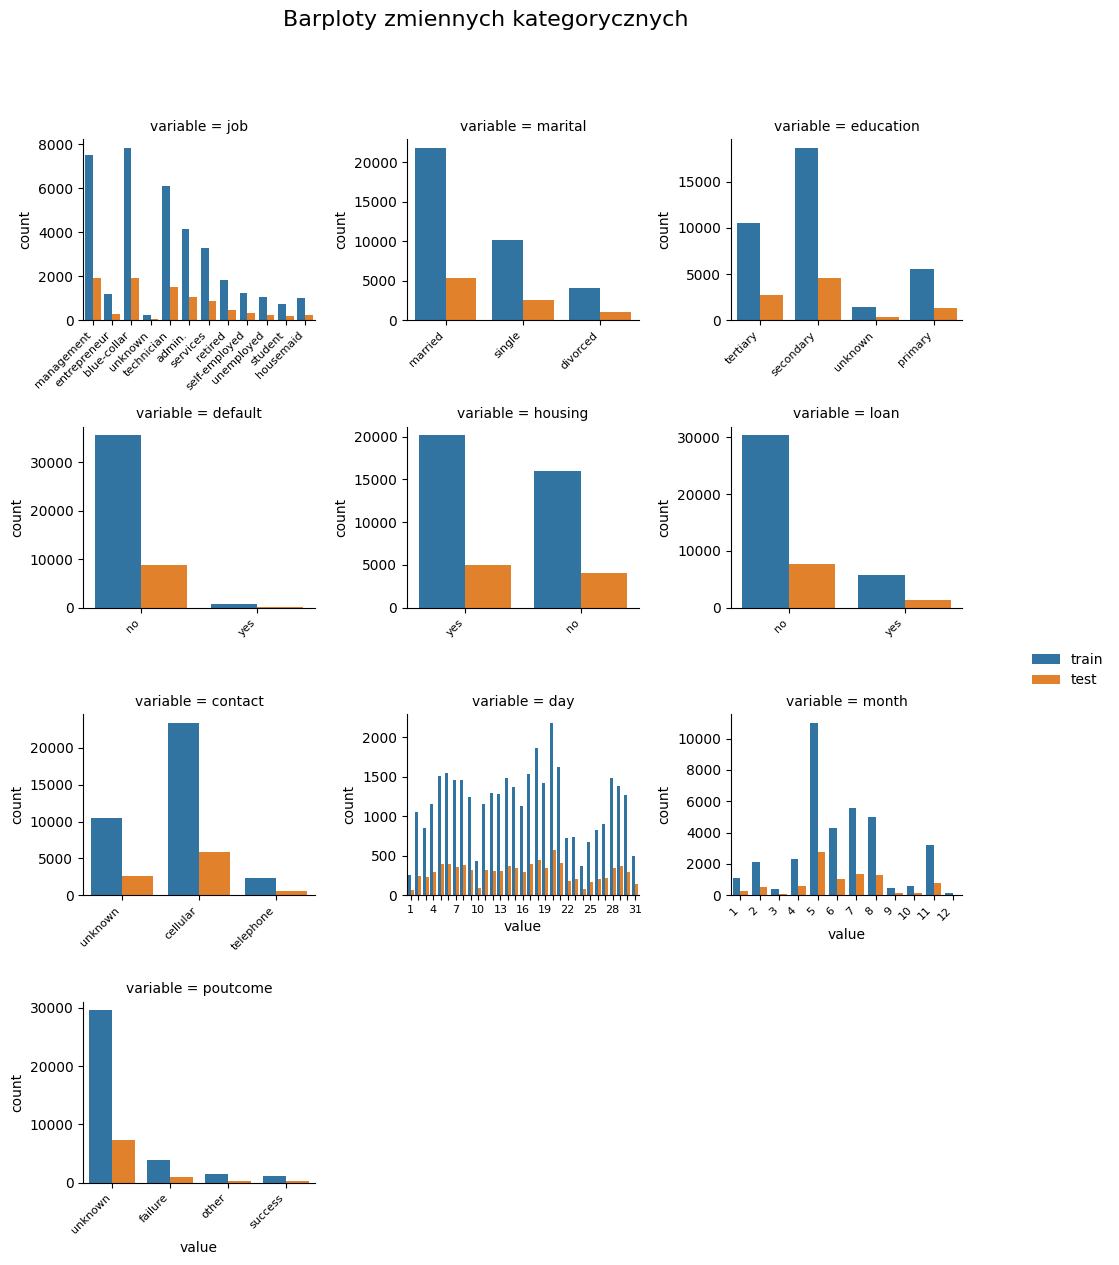

In [18]:
palette = {"train": sns.color_palette()[0], "test": sns.color_palette()[1]}

barplots = sns.FacetGrid(
    dat_long_cat,
    col='variable',
    col_wrap=3,
    sharex=False,
    sharey=False,
)

barplots_fig = barplots.map_dataframe(
    sns.countplot,
    x='value',
    hue='dataset',
    palette=palette
)

barplots_fig.fig.suptitle("Barploty zmiennych kategorycznych", y=1.05, fontsize=16)
barplots_fig.add_legend(bbox_to_anchor=(1.05, 0.5), loc='center left', borderaxespad=0.)

for ax, title in zip(barplots_fig.axes.flat, barplots_fig.col_names):
    ax.tick_params(axis='x', labelsize=8)
    
    if title in ['day']:
        labels = [label.get_text() for label in ax.get_xticklabels()]
        ax.set_xticklabels([
            lbl if i % 3 == 0 else '' 
            for i, lbl in enumerate(labels)
        ])
    else:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.show()

Liczności grup zmiennej reprezentującej posiadanie kredytu hipotecznego są bliskie, natomiast dla pozostałych zmiennych dostrzec można znaczne nierówności.

Rozkłady wszystkich cech w zbiorach treningowym i testowym są podobne. Przyjmujemy więc, że zbiory treningowy i testowy są reprezentatywne.

W kolejnych krokach będziemy posługiwać się tylko zbiorem treningowym, aby nie opierać budowy modelu na danych testowych. Na początek przeanalizujmy współczynniki korelacji Pearsona obliczone dla zmiennych ciągłych.

In [19]:
def color(value):
    if abs(value) <= 0.5:
        color = "green"
    elif 0.5 < abs(value) <= 0.9:
        color = "darkorange"
    elif abs(value) > 0.9:
        color = "red"
    else:
        color = "black"
    return "color: {0}".format(color)

pears_cor = X_train[cont].corr(method = "pearson")

pears_cor.style.applymap(color)

,age,duration,pdays,balance,campaign,previous
age,1.000000,-0.003509,-0.025930,0.095448,0.006075,-0.001760
duration,-0.003509,1.000000,-0.002338,0.022042,-0.085249,0.003000
pdays,-0.025930,-0.002338,1.000000,-0.000935,-0.089349,0.546089
balance,0.095448,0.022042,-0.000935,1.000000,-0.013979,0.019919
campaign,0.006075,-0.085249,-0.089349,-0.013979,1.000000,-0.040877
previous,-0.001760,0.003000,0.546089,0.019919,-0.040877,1.000000


Wszystkie współczynniki przyjmują wartości poniżej 0.9, co pozwala nam przyjąć, że korelacje między zmiennymi ciągłymi nie są znaczące. Korelacja między zmienną *previous* a *pdays* wynosi około 0.55, wskazując na umiarkowaną zależność między nimi.

Pogrupujmy tymczasowo zmienne ciągłe oraz *day* i *month*, aby je zdyskretyzować lub zmniejszyć liczbę ich wartości. Kolejne wykresy przedstawiają liczbę obserwacji oraz poporcję osób, które zdecydowały się na subskrypcję lokaty terminowej w każdej grupie.

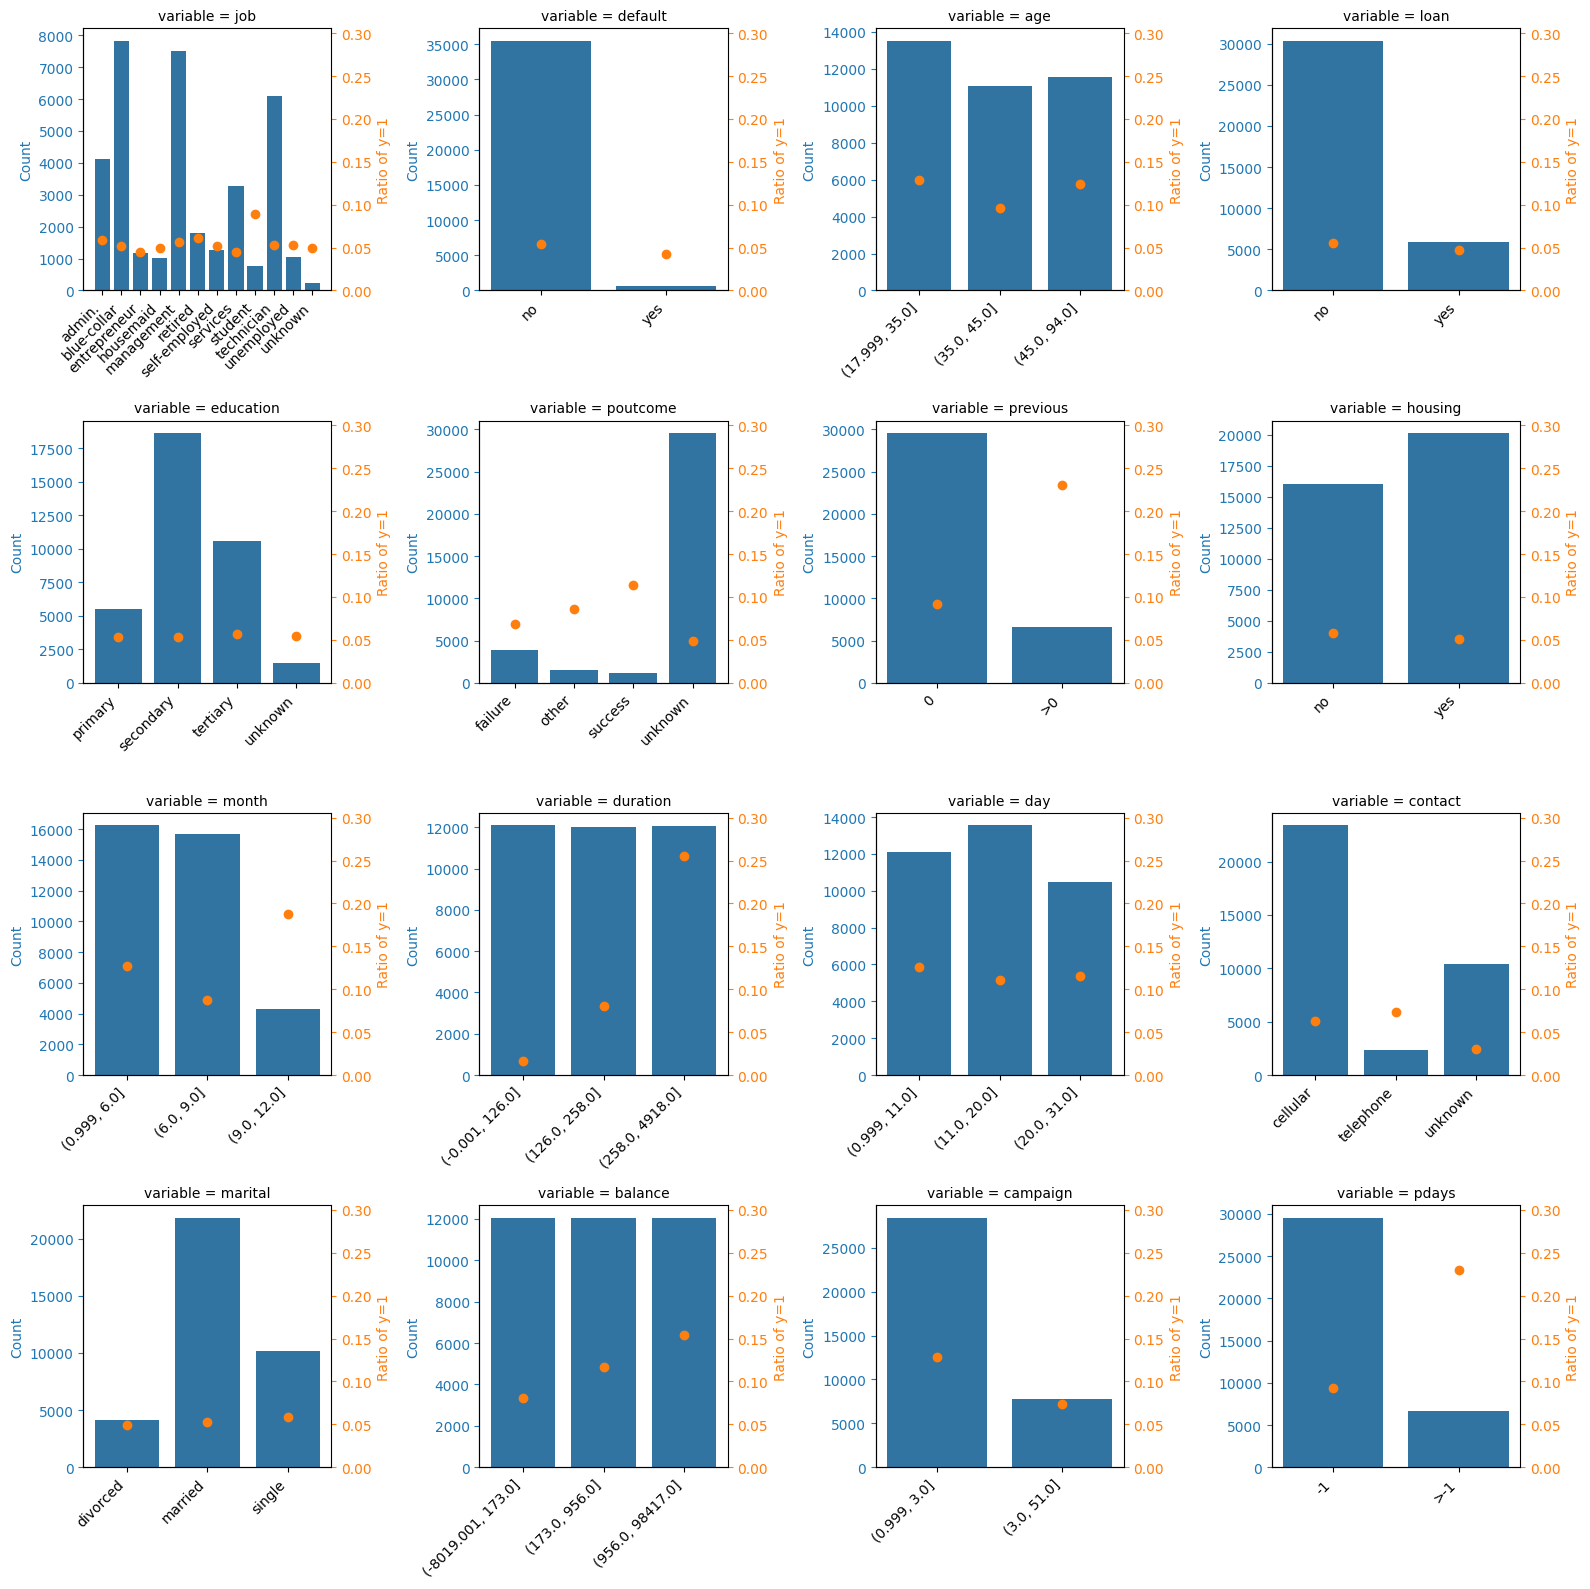

In [22]:
X_train_cat_long_list = []
train_data = data.loc[data.index.isin(X_train.index)].reset_index()

for col in X_train.columns:
    temp = X_train[[col]].join(y_train)
    
    if col in ["age", "duration", "balance", "campaign", "day", "month"]:
        temp["bin"] = pd.qcut(temp[col], q=3, duplicates = "drop")
    elif col == "pdays":
        temp["bin"] = temp[col].apply(lambda x: "-1" if x == -1 else ">-1")
    elif col == "previous":
        temp["bin"] = temp[col].apply(lambda x: "0" if x == 0 else ">0")
    else:
        temp = train_data[[col]].join(y_train)
        temp["bin"] = temp[col]

    grouped = (
        temp.groupby('bin')
        .agg(count=("y", 'size'), pos=("y", 'sum'))
        .reset_index()
    )
    grouped['variable'] = col
    grouped['ratio'] = grouped['pos'] / grouped['count']

    X_train_cat_long_list.append(grouped)

X_train_cat_long = pd.concat(X_train_cat_long_list, ignore_index=True)

g = sns.FacetGrid(X_train_cat_long, col='variable', col_wrap=4, height=4, sharey=False, sharex = False)

max_ratio = X_train_cat_long["ratio"].max()

def dual_axis_bar_point(data, **kwargs):
    ax = plt.gca()

    # Convert bin to string for plotting
    data['bin_str'] = data['bin'].astype(str)

    # Barplot (left Y-axis)
    sns.barplot(data=data, x='bin_str', y='count', ax=ax, color = sns.color_palette()[0])
    ax.set_ylabel('Count', color = sns.color_palette()[0])
    ax.tick_params(axis='y', colors = sns.color_palette()[0])
    ax.set_xlabel("")

    # Lineplot (right Y-axis)
    ax2 = ax.twinx()
    ax2.scatter(data['bin_str'], data['ratio'], color = sns.color_palette()[1], marker='o')
    ax2.set_ylabel('Ratio of y=1', color = sns.color_palette()[1])
    ax2.tick_params(axis='y', colors = sns.color_palette()[1])
    ax2.set_ylim(0, max_ratio + 0.05)

    ax.tick_params(axis='x', rotation=45)

g.map_dataframe(dual_axis_bar_point, max_ratio = max_ratio)
plt.tight_layout()

for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

plt.show()

Z wykresu odczytujemy, że kontakt przed kampanią wpłynął pozytywnie na proporcję subskrypcji, tak samo jak sukces oraz kontakt w poprzedniej kampanii, dłuższy czas trwania i późniejszy miesiąc ostatniego kontaktu, mniejsza liczba kontaktów w bieżącej kampanii oraz większe średnie roczne saldo na koncie. Dla pozostałych zmiennych różnice między grupami są mniejsze lub mniej oczywiste na powyższych wykresach.

## Budowa modelu

Na początek budujemy modele:
* na domyślnych hiperparametrach,
* na domyślnych hiperparametrach ze zmiennymi typu *dummy*,
* na hiperparametrach zoptymalizowanych przy pomocy metody Bayesa,
* na hiperparametrach zoptymalizowanych przy pomocy metody Bayesa ze zmiennymi typu *dummy*.

Przeanalizujmy uzyskane dla nich miary GINI, widoczne w poniższej tabeli.

In [23]:
model_results = pd.DataFrame(columns=[
    'name', 
    'description', 
    'parameters', 
    'gini_train', 
    'gini_test'
])

In [24]:
def gini(true_val, predicted_val):
    return 2 * roc_auc_score(true_val, predicted_val) - 1

In [25]:
def add_model_result(df, model, name, description, gini, X_train, X_test, y_train, y_test):
    
    df.loc[len(df)] = {
        'name': name,
        'description': description,
        'parameters': model.n_features_in_,
        'gini_train': gini(true_val = y_train, predicted_val = model.predict_proba(X_train)[:, 1]),
        'gini_test': gini(true_val = y_test, predicted_val = model.predict_proba(X_test)[:, 1])
    }
    return df


In [26]:
model1 = xgb.XGBClassifier()
model1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [27]:
model_results = add_model_result(model_results, model1, "model1", "domyślne hiperparametry", gini, X_train, X_test, y_train, y_test)

In [28]:
dat_dummy = pd.get_dummies(data[[i for i in data.columns if i != "y"]])

In [29]:
dat_dummy = dat_dummy.drop(columns=["job_admin.", "marital_divorced", "education_primary","default_no", "housing_no", "loan_no", "contact_cellular", "month_apr", "poutcome_failure"])

In [30]:
X_train_d = dat_dummy.iloc[X_train.index,:].copy()
X_test_d = dat_dummy.iloc[X_test.index,:].copy()

In [31]:
model2 = xgb.XGBClassifier()
model2.fit(X_train_d, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)

In [32]:
model_results = add_model_result(model_results, model2, "model2", "domyślne parametry oraz zmienne dummy", gini, X_train_d, X_test_d, y_train, y_test)

In [33]:
model_bayes = xgb.XGBClassifier()

In [34]:
param_space = {
    "n_estimators": Integer(50, 200),
    "max_depth": Integer(3, 10),
    "min_child_weight": Integer(1, 200),
    "learning_rate": Real(0.01, 0.3, prior="log-uniform"),
    "subsample": Real(0.6, 1.0),
    "colsample_bytree": Real(0.6, 1.0),
    "gamma": Real(1e-4, 10, prior="log-uniform"),
    "reg_lambda": Real(1e-4, 10, prior="log-uniform"),
    "reg_alpha": Real(1e-4, 10, prior="log-uniform")
}

In [38]:
grid_search1 = BayesSearchCV(
    estimator=model_bayes,
    search_spaces=param_space,
    scoring="neg_mean_squared_error",
    n_iter=50,
    cv=3,
    verbose=0,
    random_state=42
)

In [39]:
grid_search1.fit(X_train, y_train)

BayesSearchCV(cv=3,
              estimator=XGBClassifier(base_score=None, booster=None,
                                      callbacks=None, colsample_bylevel=None,
                                      colsample_bynode=None,
                                      colsample_bytree=None,
                                      early_stopping_rounds=None,
                                      enable_categorical=False,
                                      eval_metric=None, feature_types=None,
                                      gamma=None, gpu_id=None, grow_policy=None,
                                      importance_type=None,
                                      interaction_constraints=None,
                                      learning_rate=None...
                             'min_child_weight': Integer(low=1, high=200, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=50, high=200, prior='uniform', transform='normalize'),
                             'reg_alpha': Real(low=0.0001, high=10, prior='log-uniform', transform='normalize'),
                             'reg_lambda': Real(low=0.0001, high=10, prior='log-uniform', transform='normalize'),
                             'subsample': Real(low=0.6, high=1.0, prior='uniform', transform='normalize')})

In [40]:
model_results = add_model_result(model_results, grid_search1.best_estimator_, "model3", "zoptymalizowane hiperparametry", gini, X_train, X_test, y_train, y_test)

In [41]:
grid_search2 = BayesSearchCV(
    estimator=model_bayes,
    search_spaces=param_space,
    scoring="neg_mean_squared_error",
    n_iter=50,
    cv=3,
    verbose=0,
    random_state=42
)

In [42]:
grid_search2.fit(X_train_d, y_train)

BayesSearchCV(cv=3,
              estimator=XGBClassifier(base_score=None, booster=None,
                                      callbacks=None, colsample_bylevel=None,
                                      colsample_bynode=None,
                                      colsample_bytree=None,
                                      early_stopping_rounds=None,
                                      enable_categorical=False,
                                      eval_metric=None, feature_types=None,
                                      gamma=None, gpu_id=None, grow_policy=None,
                                      importance_type=None,
                                      interaction_constraints=None,
                                      learning_rate=None...
                             'min_child_weight': Integer(low=1, high=200, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=50, high=200, prior='uniform', transform='normalize'),
                             'reg_alpha': Real(low=0.0001, high=10, prior='log-uniform', transform='normalize'),
                             'reg_lambda': Real(low=0.0001, high=10, prior='log-uniform', transform='normalize'),
                             'subsample': Real(low=0.6, high=1.0, prior='uniform', transform='normalize')})

In [43]:
model_results = add_model_result(model_results, grid_search2.best_estimator_, "model4", "zoptymalizowane hiperparametry ze zmiennymi typu dummy", gini, X_train_d, X_test_d, y_train, y_test)

model_results

,name,description,parameters,gini_train,gini_test
0,model1,domyślne hiperparametry,16,0.957330,0.870827
1,model2,domyślne parametry oraz zmienne dummy,42,0.954925,0.872667
2,model3,zoptymalizowane hiperparametry,16,0.884578,0.873840
3,model4,zoptymalizowane hiperparametry ze zmiennymi ty...,42,0.889609,0.875038


Największą wartość GINI uzyskał model zbudowany z domyślnymi parametrami, bez zmiennych *dummy*. Przyjmujemy więc, że jest to najlepszy model.

W następnym kroku, posługując się miarą GINI, przeanalizowane zostanie zachowanie najlepszego modelu w zależności od liczby włączonych do niego najistotniejszych (w sensie drzewa decyzyjnego) zmiennych.

In [44]:
importances = model1.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False).reset_index(drop=True)

In [45]:
gini_scores_train = []
gini_scores_test = []

for i in range(1, len(feat_imp_df) + 1):
    selected_features = feat_imp_df['feature'][:i].tolist()
    
    xgb_temp = xgb.XGBClassifier()
    xgb_temp.fit(X_train[selected_features], y_train)
    
    gini_train = gini(y_train, xgb_temp.predict_proba(X_train[selected_features])[:, 1])
    gini_test = gini(y_test, xgb_temp.predict_proba(X_test[selected_features])[:, 1])
    
    gini_scores_train.append(gini_train)
    gini_scores_test.append(gini_test)

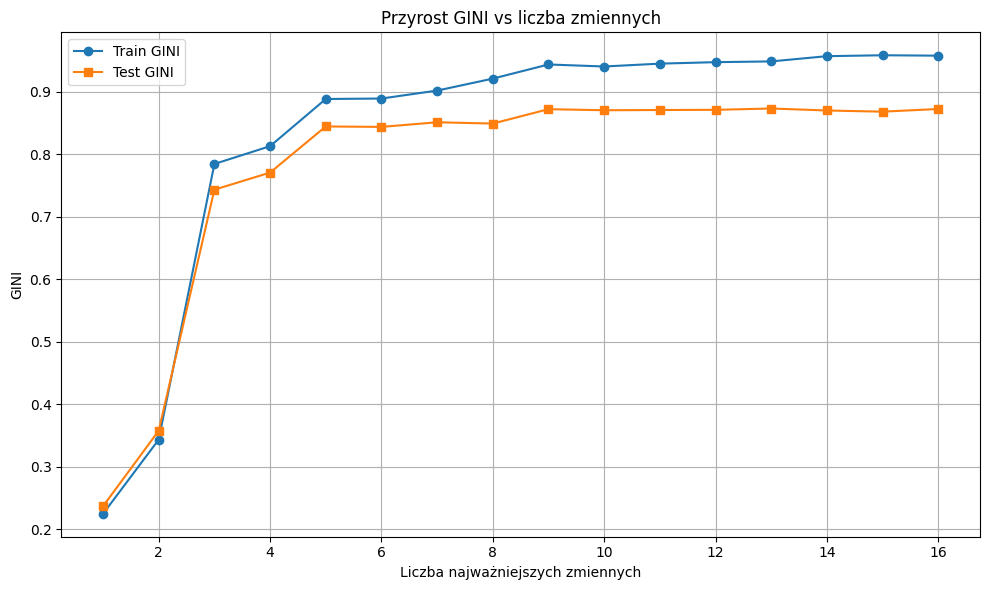

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(gini_scores_train) + 1), gini_scores_train, marker='o', label='Train GINI')
plt.plot(range(1, len(gini_scores_test) + 1), gini_scores_test, marker='s', label='Test GINI')
plt.title("Przyrost GINI vs liczba zmiennych")
plt.xlabel("Liczba najważniejszych zmiennych")
plt.ylabel("GINI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Miara GINI obliczona na podstawie zbioru treningowego rośnie jeszcze przy 9 zmiennych w modelu, natomiast gdy jest ich więcej nie zmienia się ona znacząco, co sugeruje, że dodawanie kolejnych zmiennych nie poprawia jakości predykcji. Podobne zachowanie obserujemy dla wartości GINI na podstawie zbioru testowego; dla modeli z więcej niż 9 zmiennymi zmieniają się one jeszcze mniej niż te na podstawie zbioru treningowego. Możemy więc przyjąć, że włączenie więcej niż 9 zmiennych przeucza model. Porównajmy wyniki otrzymane dla modelu z 9 zmiennymi z poprzednimi czteroma modelami.

In [58]:
selected_vars = feat_imp_df['feature'][:9].tolist()

model5 = xgb.XGBClassifier()
model5.fit(X_train[selected_vars], y_train)
add_model_result(model_results, model5, "model5", "model1 z ograniczoną liczbą zmiennych", gini, X_train[selected_vars], X_test[selected_vars], y_train, y_test)

,name,description,parameters,gini_train,gini_test
0,model1,domyślne hiperparametry,16,0.957330,0.870827
1,model2,domyślne parametry oraz zmienne dummy,42,0.954925,0.872667
2,model3,zoptymalizowane hiperparametry,16,0.884578,0.873840
3,model4,zoptymalizowane hiperparametry ze zmiennymi ty...,42,0.889609,0.875038
4,model5,model1 z ograniczoną liczbą zmiennych,9,0.943858,0.872308
5,model5,model1 z ograniczoną liczbą zmiennych,9,0.943858,0.872308


Miara GINI na podstawie zbioru treningowego dla nowego modelu zmniejszyła się nieznacznie względem modelu 1, jednak wzrosła ona dla zbioru testowego. W dalszej analizie wykorzystywać będziemy model z dziwięcioma najważniejszymi zmiennymi.

## Analiza jakości modelu

Pierwszy wykres przedstawia wartości miary GAIN dla każdej zmiennej.

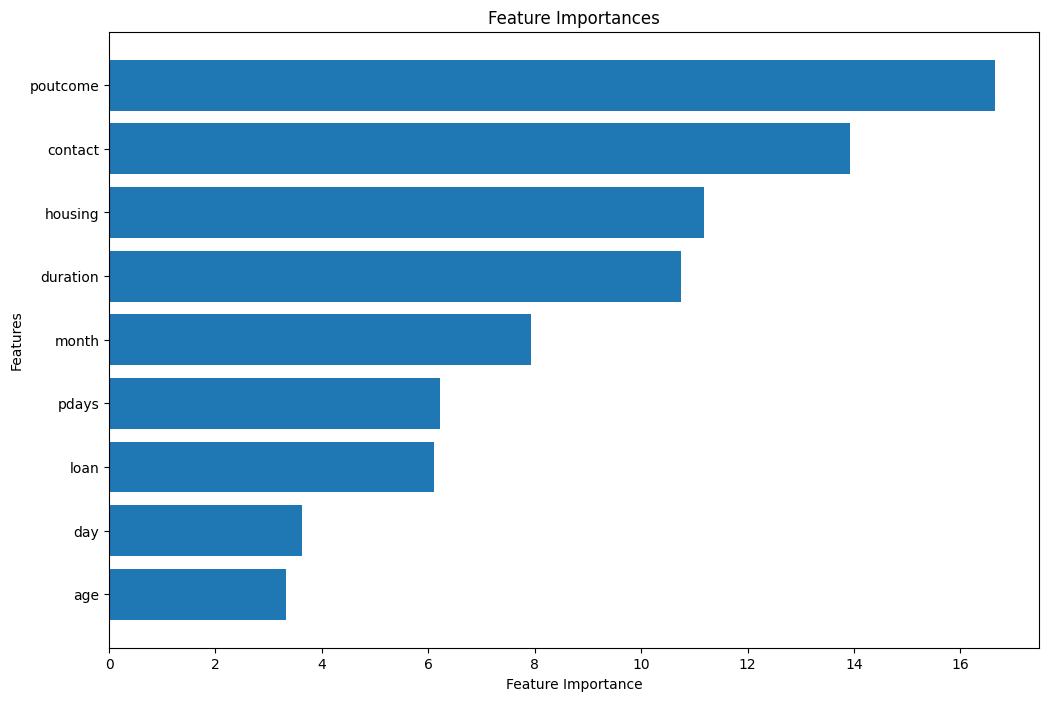

In [61]:
def plot_feature_importance(feature_names, feature_importances, title="Feature Importances"):
    df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': feature_importances
    })
    
    df = df.sort_values(by='Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    plt.barh(df['Feature'], df['Importance'], color=sns.color_palette()[0])
    plt.xlabel("Feature Importance")
    plt.ylabel("Features")
    plt.title(title)
    plt.gca().invert_yaxis() 
    plt.show()

feature_import = model5.get_booster().get_score(importance_type='gain')

feature_names = list(feature_import.keys())
feature_importances = list(feature_import.values())

plot_feature_importance(feature_names, feature_importances)

Choć analiza jednowymiarowa (wykresy proporcji *y*=1 w grupach) sugerowała silne różnicowanie przez zmienne *previous*, *balance* i *campaign*, nie znalazły się one w ostatecznym modelu. Z kolei zmienne takie jak *housing* czy *loan*, które nie różnicowały *y* wyraźnie w analizie pojedynczych zmiennych, zostały uznane przez model za istotne. Nie oznacza to jednak błędnej budowy modelu, ponieważ XGBoost bieże pod uwagę również interakcje między zmiennymi oraz wielowymiarowość danych. Zmienne które nie wydawały się początkowo istotne mogą więc być ważne w połączeniu z innymi zmiennymi i na odwrót. Co więcej, zmienna *previous* była skorelowana ze zmienną *pdays* na poziomie około 0.55, co mogło wpłynąć na wyłączenie jej z ostateczego modelu.

Z drugiej strony, zmienne takie jak *poutcome*, *duration*, *month* czy *pdays*, dla których proporcje w różnych grupach były inne, są zawarte w modelu, co pokazuje poprawność modelu.

Załóżmy teraz, że poziom cut-off wynosi 0.5. To znaczy, jeśli model przewiduje wartość większą niż 0.5, to przyjmujemy, że klient zdecydował się na subskrypcję lokaty terminowej. Przeanalizujmy macierze błędów wyznaczone dla zbioru treningowego oraz testowego i przyjętego cut-offu.

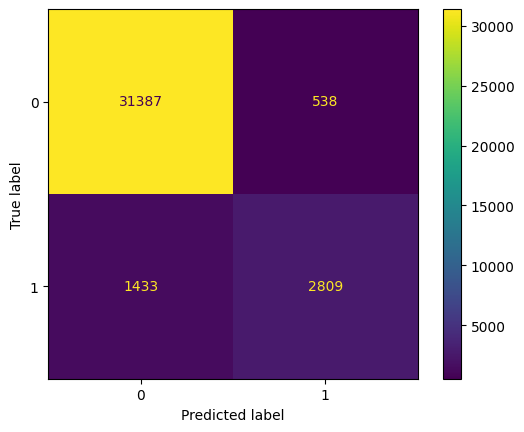

In [69]:
pred_cutoff_50 = pd.Series(model5.predict_proba(X_train[selected_vars])[:, 1]).apply(lambda x: 1 if x>0.5 else 0)
cm = confusion_matrix(y_true = y_train, y_pred = pred_cutoff_50)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=model5.classes_)
disp.plot()

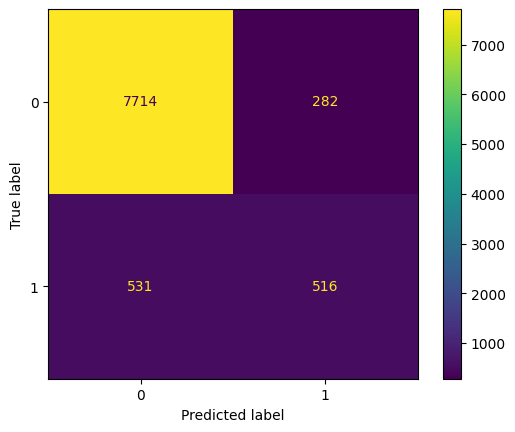

In [70]:
pred_cutoff_50_test = pd.Series(model5.predict_proba(X_test[selected_vars])[:, 1]).apply(lambda x: 1 if x>0.5 else 0)
cm_test = confusion_matrix(y_true = y_test, y_pred = pred_cutoff_50_test)
disp_test = ConfusionMatrixDisplay(confusion_matrix = cm_test, display_labels=model5.classes_)
disp_test.plot()

Dla zbioru treningowego liczba fałszywych wyników jest zdecydowanie niższa od liczby prawdziwych wyników. Z drugiej strony, dla zbioru testowego, liczba wyników fałszywie negatywnych jest podobna do liczby prawdziwych odkryć. Jednocześnie w obu przypadkach liczba wyników prawdziwie negatywnych jest duża, co jest zgodne z oczekiwaniami, ponieważ dla wielu obserwacji w zbiorze wartość *y* wynosiła 0. Aby dokładniej porównać wyniki, posłużymy się miarami przedstawionymi w poniższej tabeli.

In [71]:
def get_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return {
        "Dokładność": accuracy,
        "Moc": sensitivity,
        "Swoistość": specificity
    }

train_metrics = get_metrics(y_train, pred_cutoff_50)
test_metrics = get_metrics(y_test, pred_cutoff_50_test)

pd.DataFrame({
    "Train": train_metrics,
    "Test": test_metrics
}).T.round(3)

,Dokładność,Moc,Swoistość
Train,0.946,0.662,0.983
Test,0.910,0.493,0.965


Dokładność, czyli ogólny odsetek poprawnych predykcji, jest wysoka i podobna w obu zbiorach, co jest dobrym wynikiem. Podobnie swoistość, związana z odsetkiem wyników prawdziwie negatywnych, jest duża i podobna dla obu podzbiorów, co jest związane z dużą liczbą wyników prawdziwie negatywnych.

Dla zbioru treningowego obserujemy jednak spadek mocy w porównaniu ze zbiorem testowym. Co więcej, obie moce nie są duże. Ponieważ jednak naszym celem jest identyfikacja osób, które zasubskrybują lokatę terminową, to duża dokładność oraz swoistość modelu, nie zmieniająca się znacznie dla zbioru testowego, wpływa na ostateczną ocenę jakości modelu bardziej niż umiarkowana moc.

Przeanalizujmy również wykresy SHAP dla zbiorów treningowego oraz testowego.

 99%|===================| 8915/9043 [00:23<00:00]        

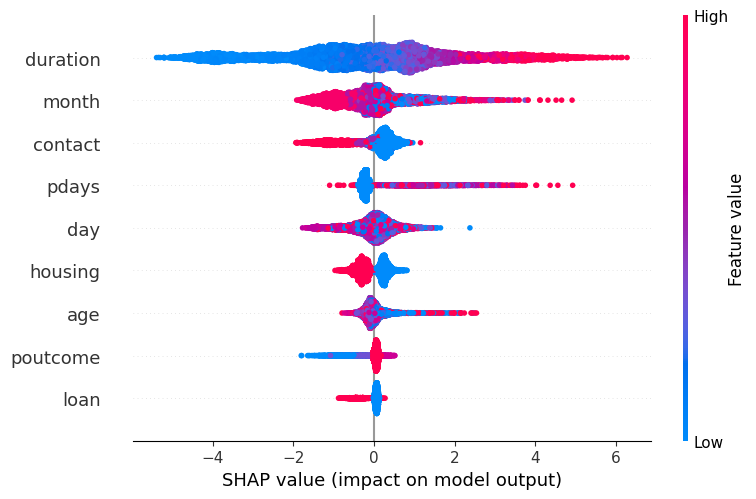

In [74]:
explainer_test = shap.TreeExplainer(model5, X_test[selected_vars])
shap_values_test = explainer_test.shap_values(X_test[selected_vars])
shap.summary_plot(shap_values_test, X_test[selected_vars])

 99%|===================| 35942/36167 [01:34<00:00]        

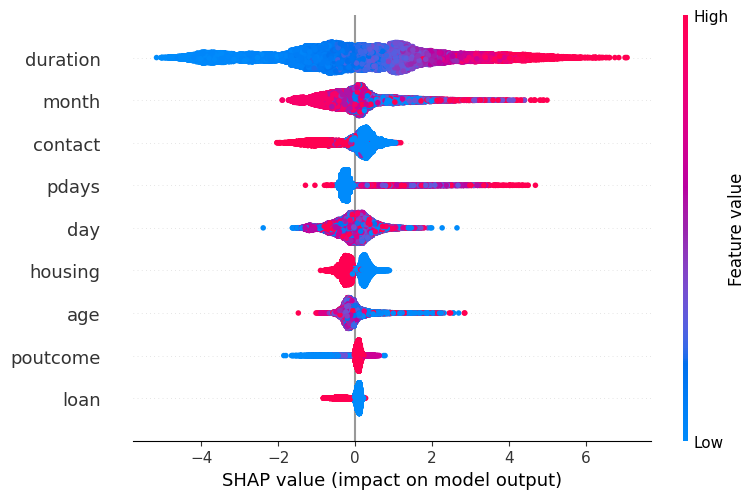

In [73]:
explainer = shap.TreeExplainer(model5, X_train[selected_vars])
shap_values = explainer.shap_values(X_train[selected_vars])
shap.summary_plot(shap_values, X_train[selected_vars])

Wykresy dla obu podzbiorów są bardzo podobne, co wskazuje na brak przeuczenia oraz stabilność modelu.

Największy wpływ na wynik mają: czas trwania, miesiąc oraz typ ostatniego kontaktu w bieżącej kampanii. Dłuższe rozmowy istotnie zwiększają prawdopodobieństwo pozytywnej decyzji, co może sugerować większe zainteresowanie klientów.

Innymi zmiennymi których w ogólności, zwiększone wartości dają wyraźnie mniejsze lub większe prawdopodobieństwo przypisania obserwacji *y*=1 są: *contact*, *pdays*, *housing*, *poutcome* oraz *loan*. Zauważmy, że wszystkie zmienne wykazujące tę cechę otrzymały wysoki wynik GAIN, a wsród nich jedyną zmienną, która również była określona przez tę miarę jako ważna ale jej wartości nie były proporcjonalne do wpływu na wynik predykcji była zmienna *month* (która na powyższych wykresach SHAP jest druga w kolejności).

Zmienne reprezentujące wiek oraz dzień i miesiąc ostatniego kontaktu nie wpływają na model proporcjonalnie z ich wartościami, co może wiązać się występującymi zależnościami sezonowymi, które w przypadku tych cech są naturalne.

## Podsumowanie

W raporcie posłużyliśmy się danymi bankowymi aby zbudować model przewidujący, czy klient zdecyduje się na subskrypcję lokaty terminowej. Na początek przeanalizowany został rozkład zmiennych oraz zależności między nimi, a także zależności między predyktorami a zmienną objaśnianą.

Następnie, zbudowane zostały modele z domyślnymi hiperparametrami, wykorzystujące optymalizację Bayesowską oraz zawierające zmienne typu *dummy*. Ostatecznie jako najlepszy model wybrany został ten z domyślnymi hiperparametrami bez zmiennych *dummy*, a następnie zmniejszyliśmy liczbę zawartych w nim zmiennych z 16 na 9 najważniejszych, wybranych przy pomocy miary ważności związanej z drzewami decyzyjnymi.

Analiza jakości modelu wykazała, że istotnymi zmiennymi są między innymi te związane z ostatnim kontaktem w bieżącej kampanii oraz poprzednią kampanią. Oprócz tego, ostateczny model wykorzystuje również zmienne dotyczące wieku, kredytu hipotecznego i gotówkowego.

Dla cut-off na poziomie 0.5, mimo umiarkowanej mocy, model dobrze zidentyfikował klientów, którzy nie zdecydowali się na subskrypcję lokaty. Takie zachowanie modelu może być przydatne w praktyce, ponieważ pozwala ograniczyć koszty nieefektywnego kontaktu. Ponadto, stabilność wyników pomiędzy zbiorem treningowym i testowym oraz zgodność ważnych zmiennych w analizie GAIN i SHAP potwierdzają brak przeuczenia zbudowanego modelu.